Bohanec, M. (1988). Car Evaluation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5JP48.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading

In [ ]:
cols = ['Buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv("car.data", names=cols)

# 2. Data Preprocessing (Categorical Encoding)

In [ ]:
import pandas as pd

# Define mappings for ordinal features
buying_maint_map = {'vhigh': 4, 'high': 3, 'med': 2, 'low': 1}
doors_persons_map = {'2': 2, '3': 3, '4': 4, '5more': 5, 'more': 5}
lug_boot_map = {'small': 1, 'med': 2, 'big': 3}
safety_map = {'low': 1, 'med': 2, 'high': 3}
class_map = {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}

# Apply mappings to convert categorical features to numerical
df['Buying'] = df['Buying'].map(buying_maint_map)
df['maint'] = df['maint'].map(buying_maint_map)
df['doors'] = df['doors'].map(doors_persons_map)
df['persons'] = df['persons'].map(doors_persons_map)
df['lug_boot'] = df['lug_boot'].map(lug_boot_map)
df['safety'] = df['safety'].map(safety_map)

# Convert the target variable 'class' to numerical
df['class'] = df['class'].map(class_map)

# Separate features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

print("DataFrame after encoding categorical features and target:")
display(df.head())

DataFrame after encoding categorical features and target:


,Buying,maint,doors,persons,lug_boot,safety,class
0,4,4,2,2,1,1,0
1,4,4,2,2,1,2,0
2,4,4,2,2,1,3,0
3,4,4,2,2,2,1,0
4,4,4,2,2,2,2,0


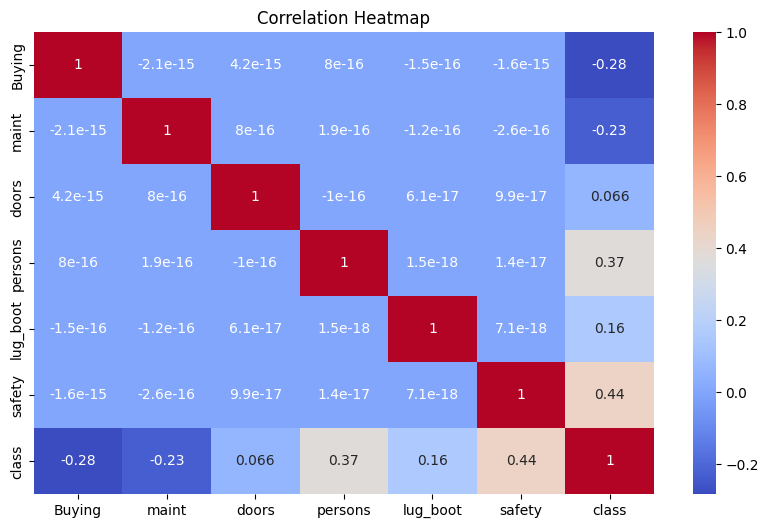

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 3. Exploratory Data Analysis (EDA)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate the classifier by adding parentheses
model = xgb.XGBRFClassifier(random_state=42)
model.fit(X_train, y_train)

xgb_y_pred = model.predict(X_test)

# 4. Model Training and Evaluation

In [ ]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

nn_model.fit(X_train, y_train)

nn_y_pred = nn_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix

def print_model_metrics(model_name, y_true, y_pred):
    print(f"\n--- Metrics for {model_name} ---")
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

# Assuming xgb_y_pred and nn_y_pred are available from previous cells
print_model_metrics("XGBoost Classifier", y_test, xgb_y_pred)
print_model_metrics("MLP Classifier", y_test, nn_y_pred)


--- Metrics for XGBoost Classifier ---
Accuracy: 0.9335
F1 Score: 0.9386
Precision: 0.9582
Recall: 0.9335
Confusion Matrix:
[[234   1   0   0]
 [  1  63  12   7]
 [  0   0   9   2]
 [  0   0   0  17]]

--- Metrics for MLP Classifier ---
Accuracy: 0.9711
F1 Score: 0.9714
Precision: 0.9730
Recall: 0.9711
Confusion Matrix:
[[234   1   0   0]
 [  3  78   2   0]
 [  0   0  10   1]
 [  0   1   2  14]]


# 5. Hyperparameter Tuning for XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV
import numpy as np # Added for np.unique

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'subsample': [0.7, 0.9, 1.0]
}

# Initialize GridSearchCV with XGBClassifier
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='multi:softmax', # Objective for multi-class classification
        num_class=len(np.unique(y_train)), # Dynamically get number of classes
        eval_metric='mlogloss',
        random_state=42
    ),
    param_grid=param_grid,
    scoring='f1_weighted', # Keep f1_weighted for imbalanced classes
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1-weighted score (CV): {grid_search.best_score_:.4f}")

# Get the best model
best_xgb_model = grid_search.best_estimator_

# Make predictions with the best model
best_xgb_y_pred = best_xgb_model.predict(X_test)

# Evaluate the best model
print_model_metrics("Optimized XGBoost Classifier", y_test, best_xgb_y_pred)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.9}
Best F1-weighted score (CV): 0.9913

--- Metrics for Optimized XGBoost Classifier ---
Accuracy: 0.9827
F1 Score: 0.9837
Precision: 0.9871
Recall: 0.9827
Confusion Matrix:
[[235   0   0   0]
 [  0  79   4   0]
 [  0   0  11   0]
 [  0   1   1  15]]


This process might take a while depending on the size of the parameter grid and your dataset. Once complete, it will output the best combination of parameters and the accuracy achieved with those parameters using cross-validation. Finally, we evaluate the best model on the test set.

# 6. Model Prediction on New Data

In [ ]:
import pandas as pd

# Create a new data point for prediction
# This should have the same structure and encoding as X_train
# Example values (using the mappings defined earlier):
# Buying: high (3), maint: med (2), doors: 4, persons: 4, lug_boot: big (3), safety: high (3)
new_data = pd.DataFrame({
    'Buying': [2],
    'maint': [1],
    'doors': [4],
    'persons': [2],
    'lug_boot': [3],
    'safety': [3]
})

print("New data point for prediction:")
display(new_data)

# Make prediction using the best_xgb_model
new_prediction = best_xgb_model.predict(new_data)

# Map the numerical prediction back to the original class name for better understanding
# Reverse the class_map to get class names from numerical values
reverse_class_map = {v: k for k, v in class_map.items()}
predicted_class_name = reverse_class_map[new_prediction[0]]

print(f"\nPredicted class for the new data point (numerical): {new_prediction[0]}")
print(f"Predicted class for the new data point (category): {predicted_class_name}")

New data point for prediction:


,Buying,maint,doors,persons,lug_boot,safety
0,2,1,4,2,3,3



Predicted class for the new data point (numerical): 0
Predicted class for the new data point (category): unacc


In [ ]:
# Find and print similar data points from the original DataFrame (df)
# We'll compare each feature of new_data with the features in df

# Create a boolean mask for each feature, wrapped in outer parentheses for clarity
mask = ((df['Buying'] == new_data['Buying'].iloc[0]) &
        (df['maint'] == new_data['maint'].iloc[0]) &
        (df['doors'] == new_data['doors'].iloc[0]) &
        (df['persons'] == new_data['persons'].iloc[0]) &
        (df['lug_boot'] == new_data['lug_boot'].iloc[0]) &
        (df['safety'] == new_data['safety'].iloc[0]))

# Filter the DataFrame using the mask
similar_data_points = df[mask]

print("\nExisting data points in 'df' similar to the new data point:")
if not similar_data_points.empty:
    display(similar_data_points)
    print(f"Number of similar data points found: {len(similar_data_points)}")
else:
    print("No exact matching data points found in the original dataset.")


Existing data points in 'df' similar to the new data point:


,Buying,maint,doors,persons,lug_boot,safety,class
1250,2,1,4,2,3,3,0


Number of similar data points found: 1
